In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install pillow

In [3]:
from PIL import Image
import os

dataset_path = "/content/drive/MyDrive/Colab Notebooks/Animal Dataset"

fixed = 0
deleted = 0

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path).convert("RGB")
            img.save(path, "JPEG")
            fixed += 1

        except:
            os.remove(path)
            deleted += 1

print("Images converted:", fixed)
print("Images removed:", deleted)

Images converted: 532
Images removed: 0


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [5]:
print(tf.__version__)

2.19.0


In [6]:
dataset_path = "/content/drive/MyDrive/Colab Notebooks/Animal Dataset"

img_size = (224,224)
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 532 files belonging to 5 classes.
Using 426 files for training.
Found 532 files belonging to 5 classes.
Using 106 files for validation.


In [7]:
class_names = train_dataset.class_names
print(class_names)

['cat', 'cow', 'dog', 'lamb', 'zebra']


In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [9]:
normalization_layer = layers.Rescaling(1./255)

In [10]:
model = models.Sequential([

    data_augmentation,
    normalization_layer,

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(256,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(5,activation='softmax')
])

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30
)

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 753ms/step - accuracy: 0.1972 - loss: 1.7566 - val_accuracy: 0.1698 - val_loss: 1.5970
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 682ms/step - accuracy: 0.2559 - loss: 1.5767 - val_accuracy: 0.3396 - val_loss: 1.4399
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 729ms/step - accuracy: 0.3404 - loss: 1.4335 - val_accuracy: 0.5660 - val_loss: 1.1609
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 812ms/step - accuracy: 0.4577 - loss: 1.2450 - val_accuracy: 0.4528 - val_loss: 1.2392
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 785ms/step - accuracy: 0.5000 - loss: 1.1623 - val_accuracy: 0.3396 - val_loss: 1.3995
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 666ms/step - accuracy: 0.5775 - loss: 1.0039 - val_accuracy: 0.5566 - val_loss: 1.0625
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 739ms/step - accuracy: 0.5775 - loss: 1.0006 - val_accuracy: 0.4528 - val_loss: 1.8716
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 830ms/step - accuracy: 0.5939 - loss: 0.9671 - val_accura

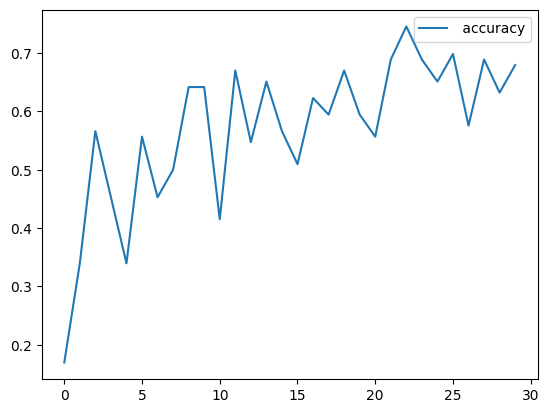

In [24]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(val_acc,label=' accuracy')
plt.legend()
plt.show()

In [25]:
print(" Accuracy:", history.history['val_accuracy'][-1]*100,"%")

 Accuracy: 67.92452931404114 %
